In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

c:\Users\la7tim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    
num_clients = 5
partitions = {
    "dirichlet_iid":      dirichlet_partition(train_dataset, num_clients=num_clients, alpha=1000.0),  # High alpha -> IID-like
    "dirichlet_noniid":   dirichlet_partition(train_dataset, num_clients=num_clients, alpha=0.01),   # Low alpha -> non-IID
    "dirichlet_medium":   dirichlet_partition(train_dataset, num_clients=num_clients, alpha=0.5),   # Medium skew
}



c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\data_partition.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)


In [4]:

from models.tinyProp import TinyPropParams

tinyprop_params = TinyPropParams(
    S_min=0.3,  
    S_max=0.9,  
    zeta=0.95,  
    number_of_layers=2  
)

   
os.makedirs('results', exist_ok=True)

In [5]:
from clients.aggregators import sparse_fedavg_aggregate
# First, let's create a function to run training for each partition
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    history = federated_training(
        client_datasets=client_datasets,
        model_name='mnist',
        testset=test_dataset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/mnist1_{partition_name}_training_log.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000
    )
    
    return model, history

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue



Starting training for DIRICHLET_IID partition...

Training on partition: DIRICHLET_IID

Round 1/100

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 0.8055
  - Accuracy: 78.53%
  - Smoothed Phi: 0.7710
  - Skipped Batches: 39
  - Current Sparsity: 0.0964
  - Average Gradient Norm: 4.7400
  - Peak Memory: 854.0MB

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 0.7080
  - Accuracy: 79.95%
  - Smoothed Phi: 0.7909
  - Skipped Batches: 52
  - Current Sparsity: 0.1008
  - Average Gradient Norm: 4.0025
  - Peak Memory: 883.0MB

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 0.6214
  - Accuracy: 79.52%
  - Smoothed Phi: 0.6509
  - Skipped Batches: 73
  - Current Sparsity: 0.1220
  - Average Gradient Norm: 3.7046
  - Peak Memory: 886.5MB

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 0.6873
  - Accuracy: 80.

Found IID results at results/mnist1_dirichlet_iid_training_log.csv
Found Non-IID results at results/mnist1_dirichlet_noniid_training_log.csv
Found Medium results at results/mnist1_dirichlet_medium_training_log.csv


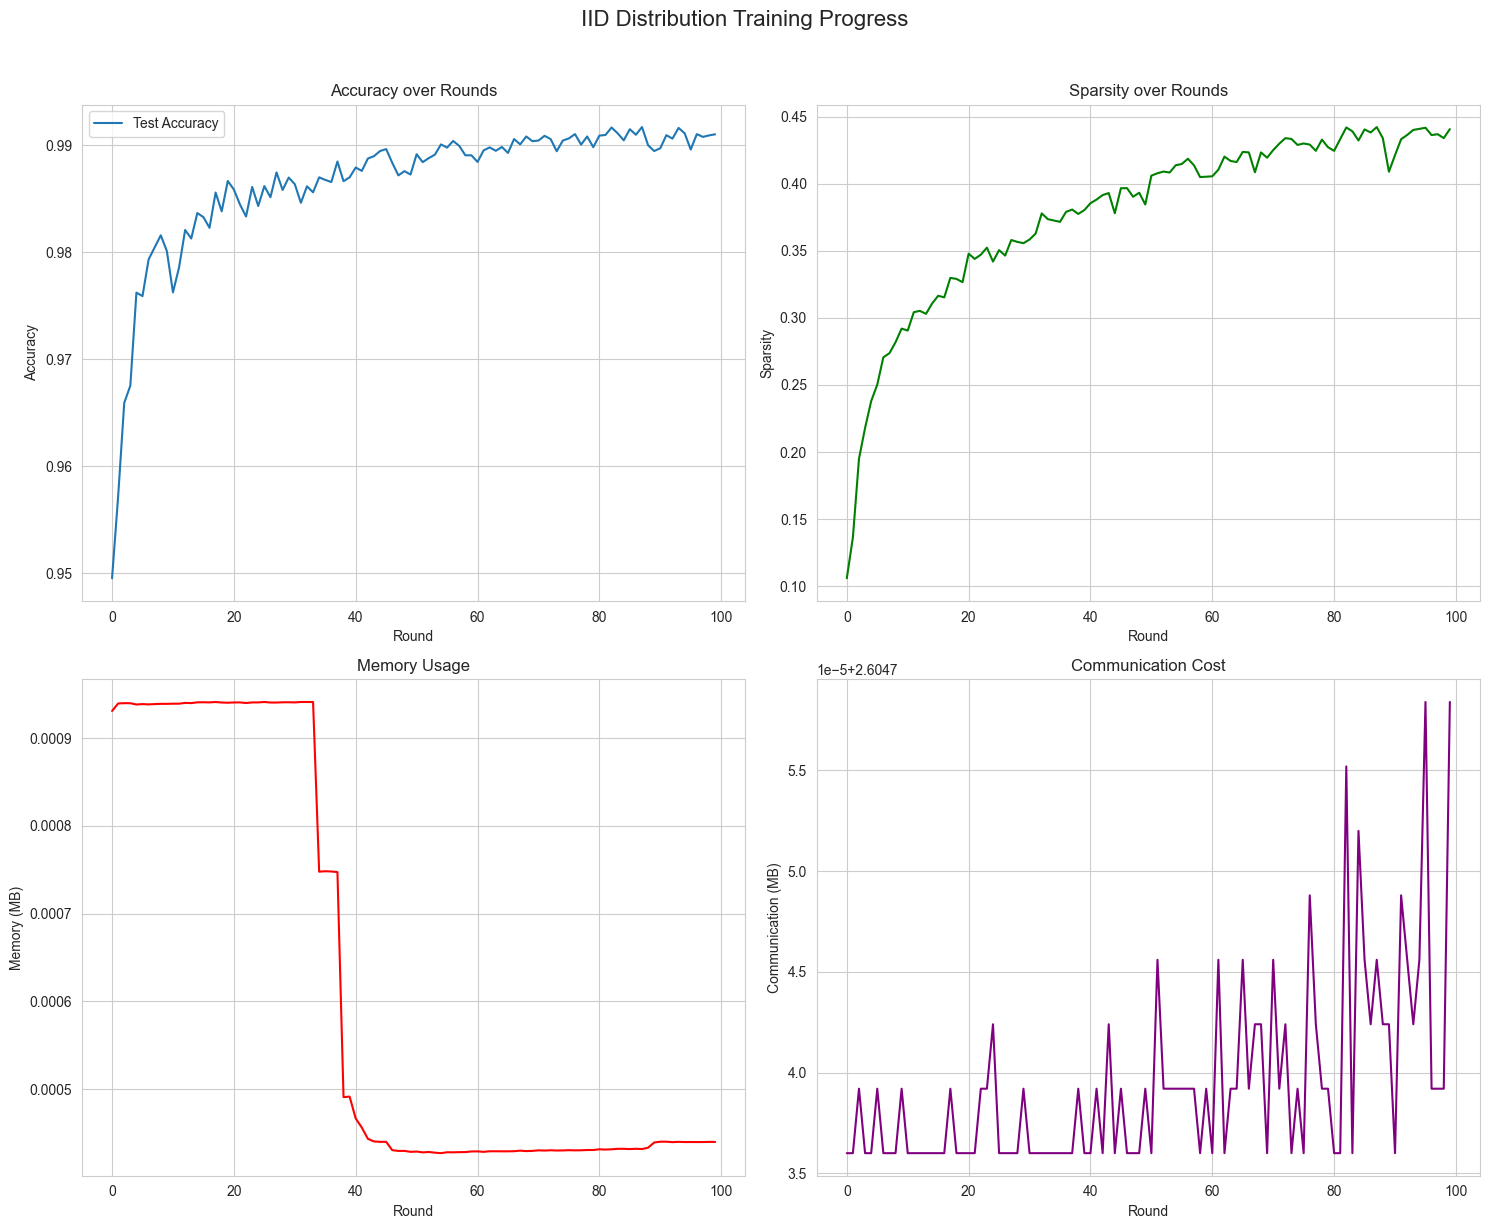

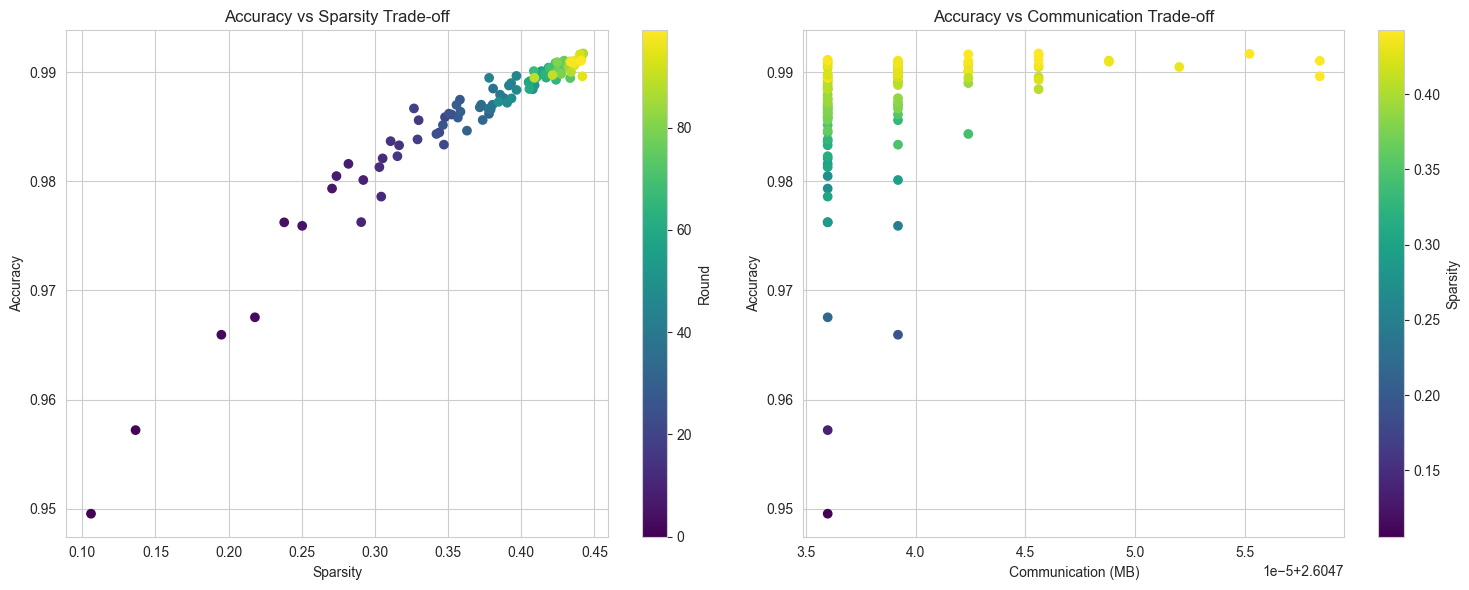

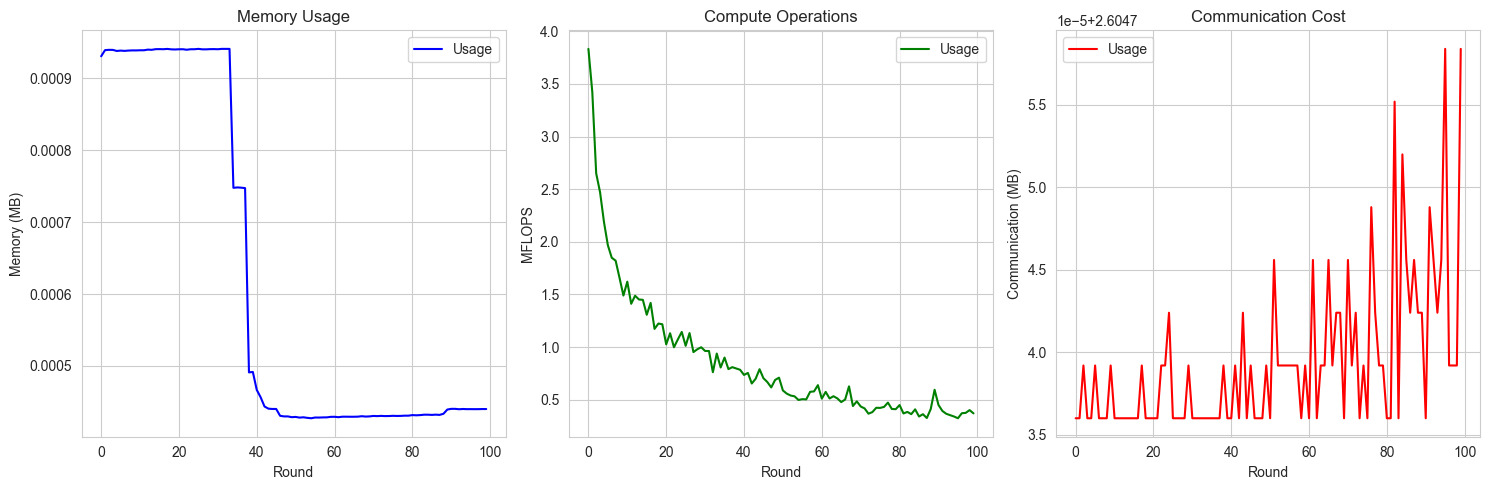

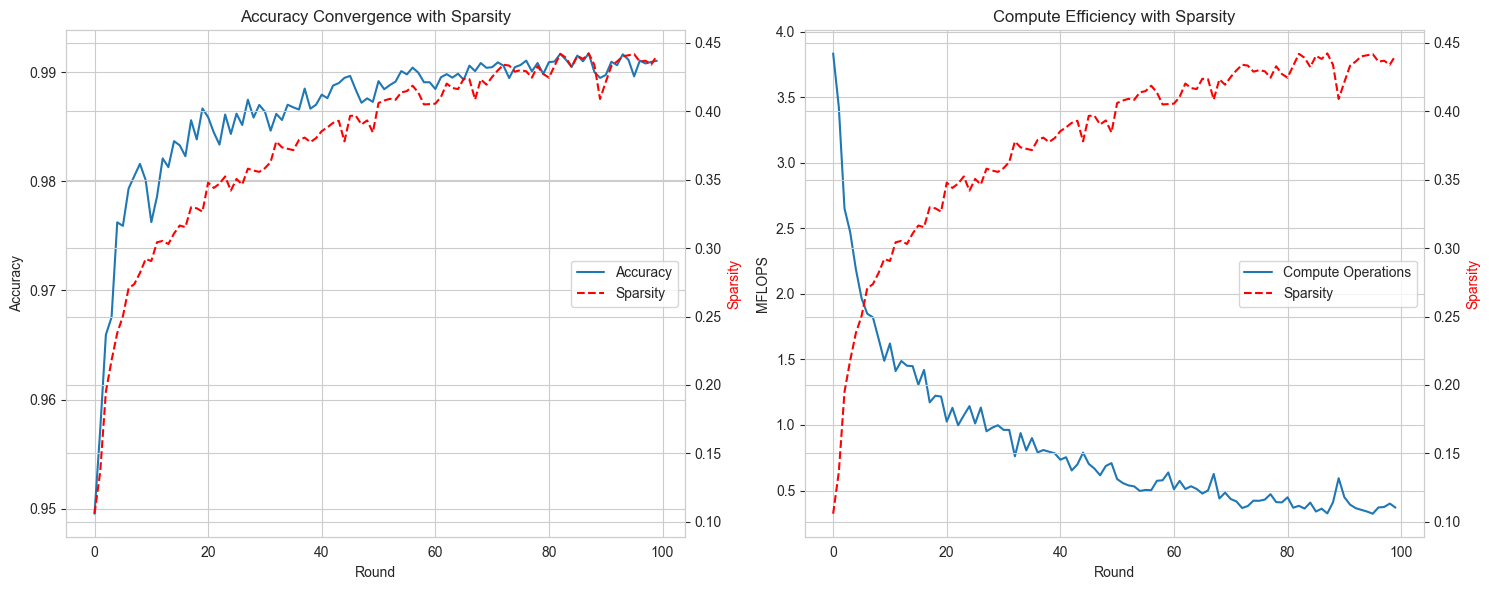

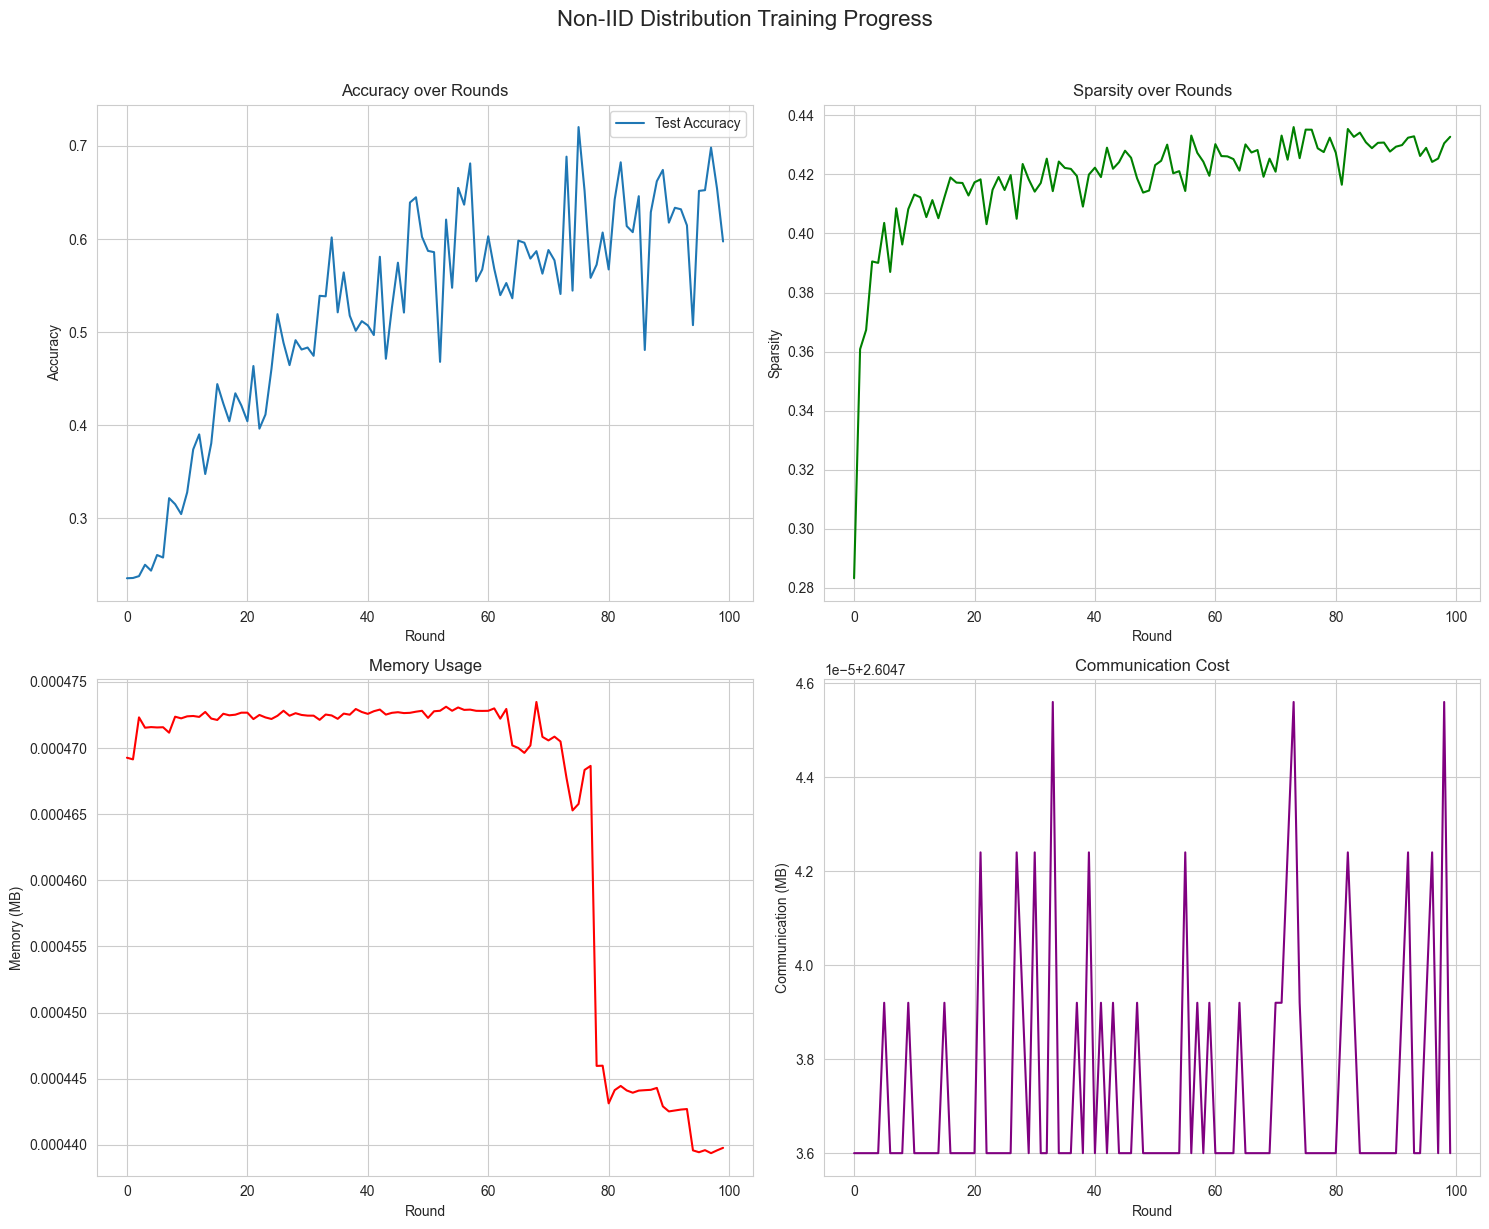

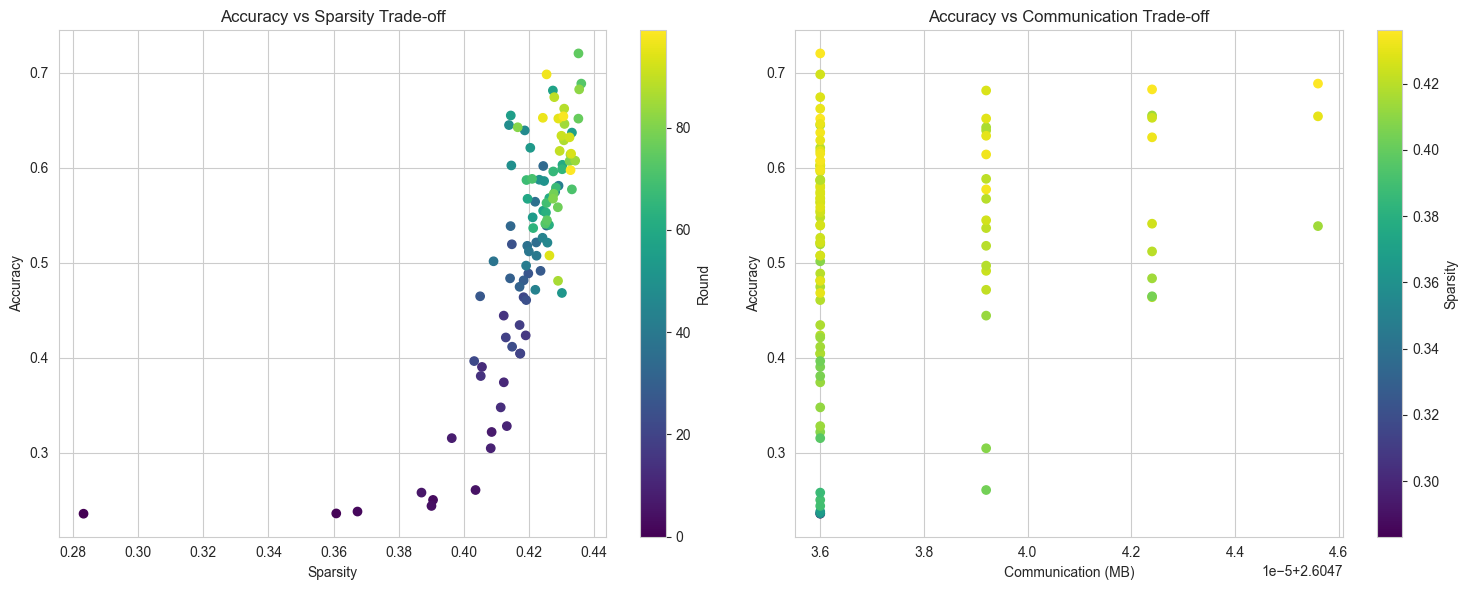

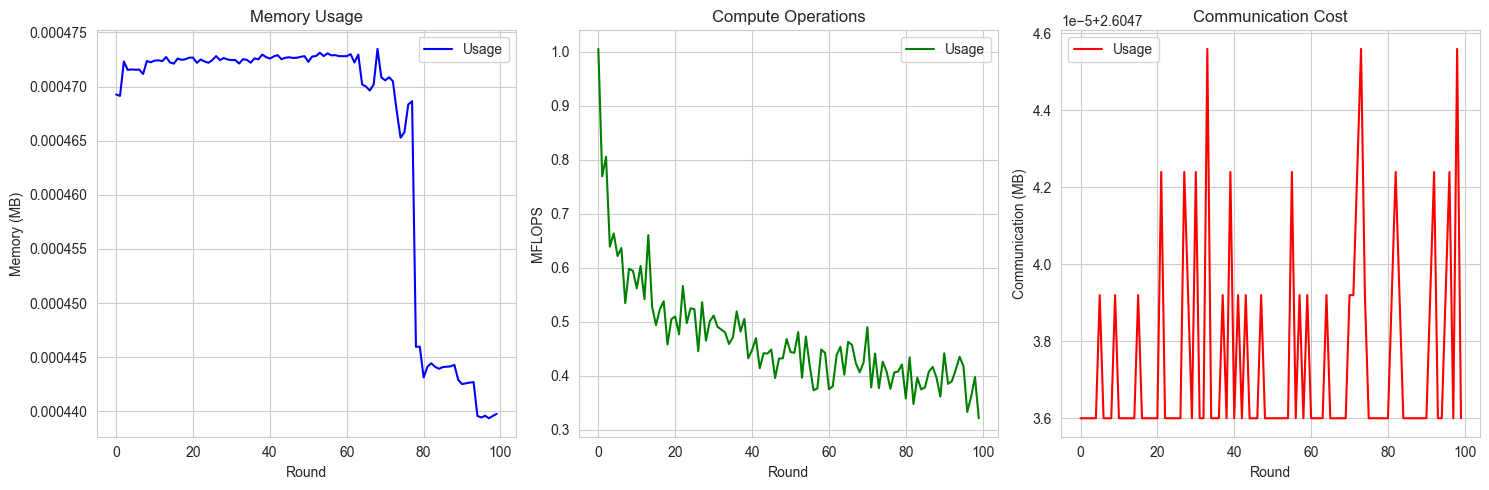

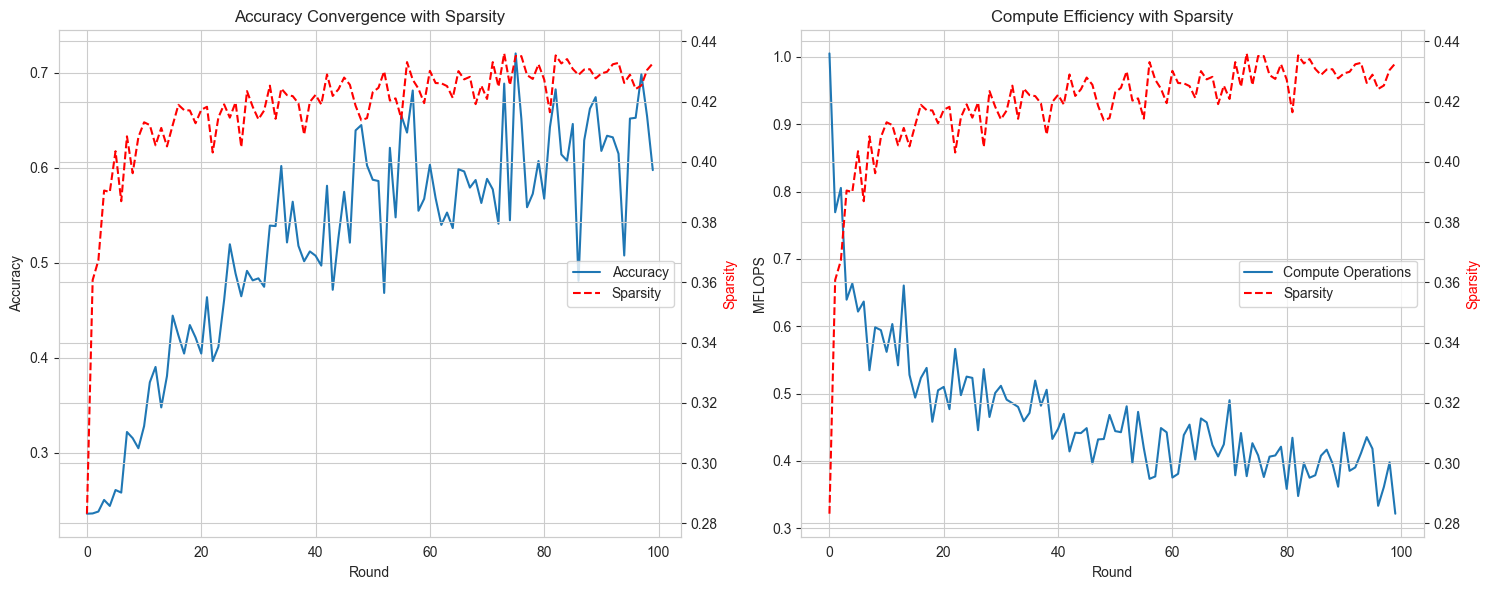

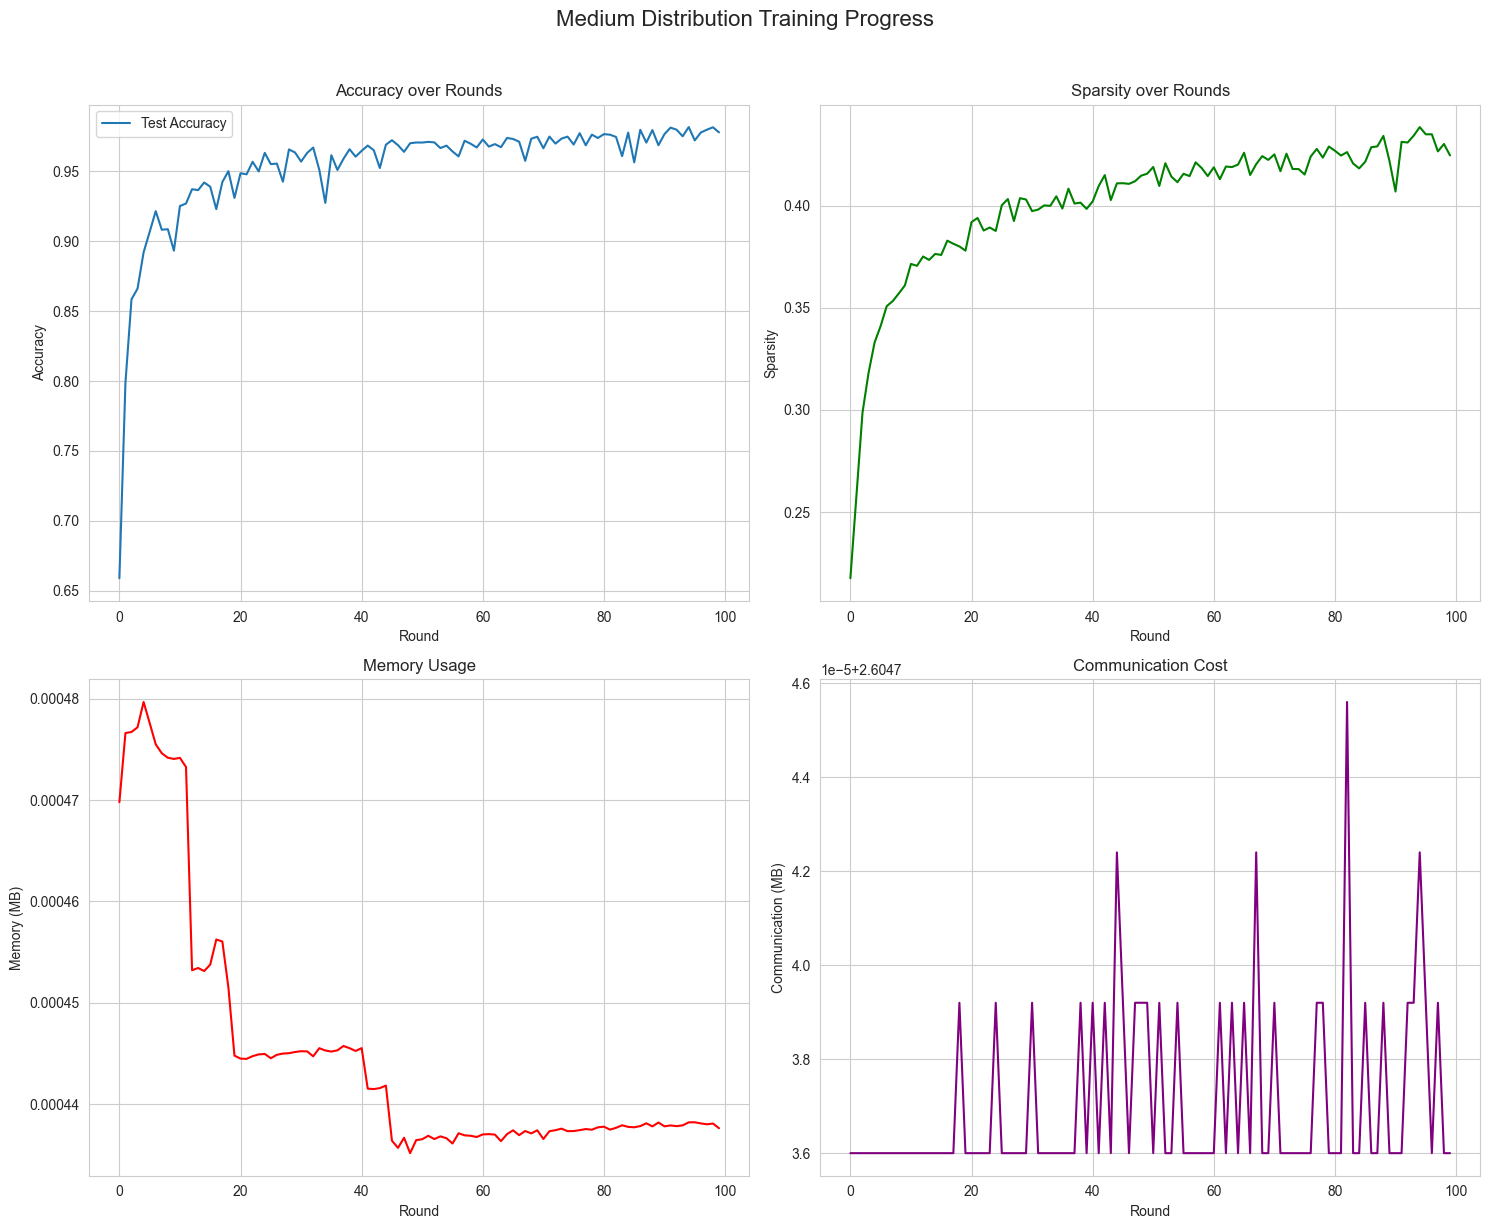

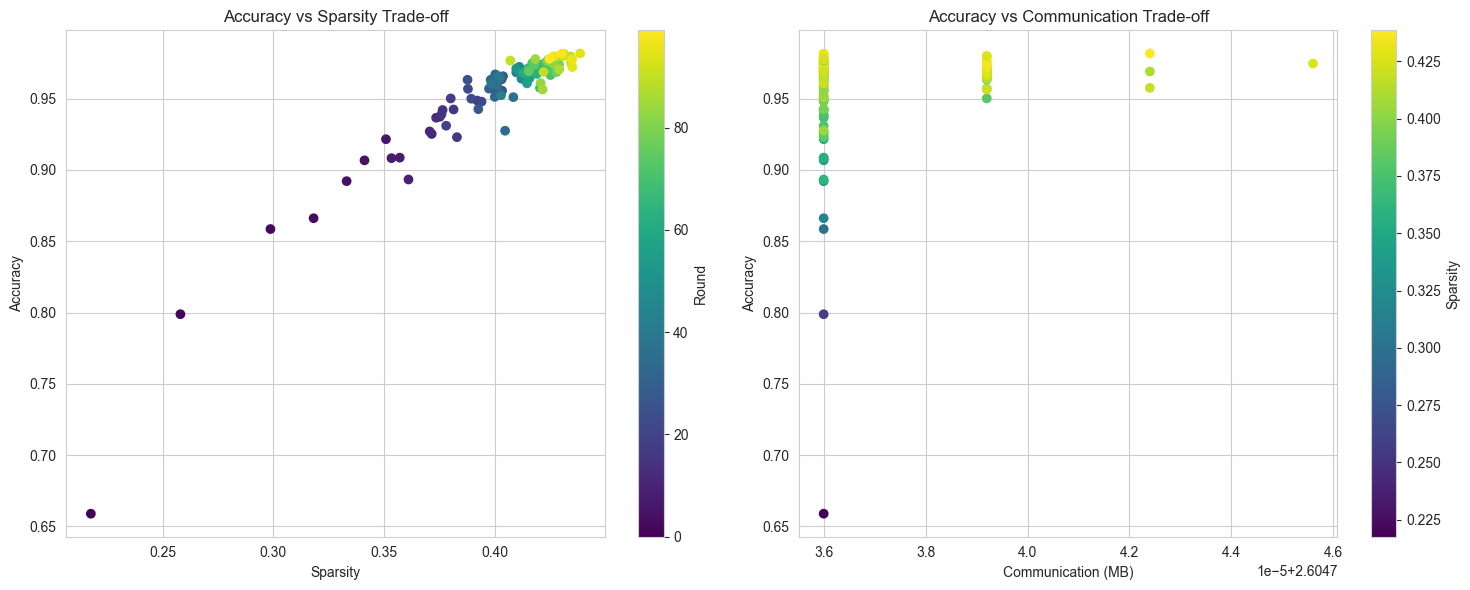

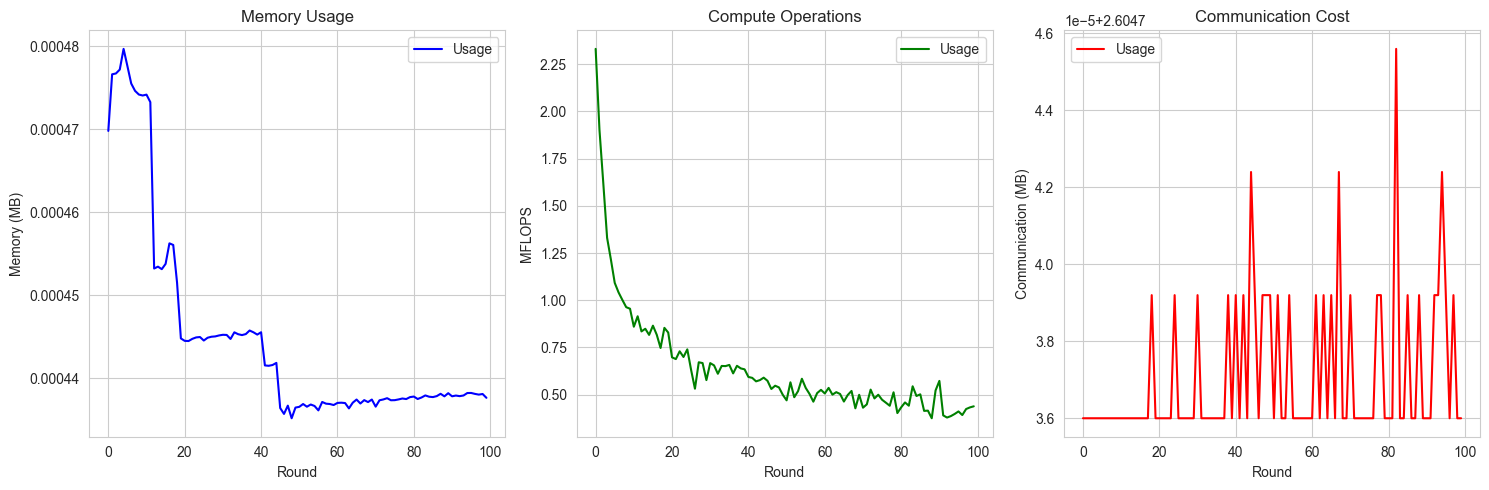

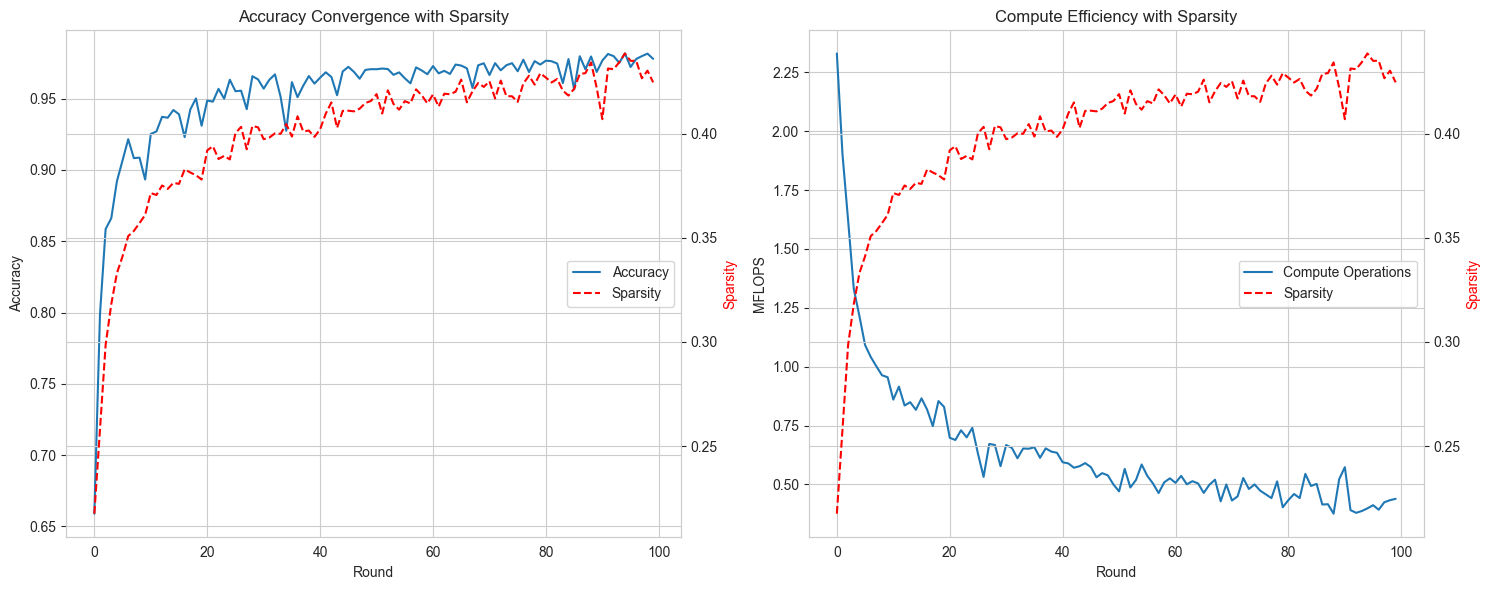


Summary Statistics:
         Final Accuracy  Max Accuracy  Average Memory (MB)  \
IID             0.99104       0.99172             0.000619   
Non-IID         0.59738       0.72020             0.000465   
Medium          0.97792       0.98172             0.000445   

         Average Communication (MB)  Average FLOPS (MFLOPS)  Final Sparsity  \
IID                        2.604739                0.856510        0.440715   
Non-IID                    2.604737                0.469818        0.432741   
Medium                     2.604737                0.641510        0.424572   

         Compression Ratio  Effective Compute Ratio  
IID               1.787996                 0.053903  
Non-IID           1.762863                 0.181411  
Medium            1.737837                 0.108256  


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.visualization import (
    plot_training_metrics,
    plot_efficiency_metrics,
    plot_hardware_profile,
    plot_convergence_analysis
)


csv_paths = {
    'IID': 'results/mnist1_dirichlet_iid_training_log.csv',
    'Non-IID': 'results/mnist1_dirichlet_noniid_training_log.csv',
    'Medium': 'results/mnist1_dirichlet_medium_training_log.csv'
}

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        print(f"Found {partition} results at {path}")
    except FileNotFoundError:
        print(f"Warning: Could not find {partition} results at {path}")

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        history = {
            'accuracy': df['accuracy'].values,
            'sparsity': df['sparsity'].values,
            'memory_bytes': df['memory_bytes'].values,
            'communication_bytes': df['communication_bytes'].values,
            'flops': df['flops'].values
        }
        plot_training_metrics(history, title_prefix=f"{partition} Distribution")
        plot_efficiency_metrics(history)
        plot_hardware_profile(history)
        plot_convergence_analysis(history)
    except Exception as e:
        print(f"Error plotting {partition} results: {e}")


summary_stats = {}
for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        summary_stats[partition] = {
            'Final Accuracy': df['accuracy'].iloc[-1],
            'Max Accuracy': df['accuracy'].max(),
            'Average Memory (MB)': df['memory_bytes'].mean() / 1e6,
            'Average Communication (MB)': df['communication_bytes'].mean() / 1e6,
            'Average FLOPS (MFLOPS)': df['flops'].mean() / 1e6,
            'Final Sparsity': df['sparsity'].iloc[-1],
            'Compression Ratio': 1 / (1 - df['sparsity'].iloc[-1]),
            'Effective Compute Ratio': (1 - df['sparsity'].iloc[-1]) * df['flops'].iloc[-1] / df['flops'].iloc[0]
        }
    except Exception as e:
        print(f"Error calculating statistics for {partition}: {e}")

summary_df = pd.DataFrame(summary_stats).T
print("\nSummary Statistics:")
print(summary_df)

1/ Accuracy Progression:
- IID: Started at ~95% and reached ~99% accuracy
- Medium: Started at ~66% and reached ~98% accuracy
- Non-IID: Started at ~24% and only reached ~70% accuracy
2/ Key Differences in Training Dynamics:
a) Initial Learning:
- IID: Strong initial performance (95% accuracy) due to balanced data distribution
- Medium: Moderate initial performance (66% accuracy) with some data imbalance
- Non-IID: Very poor initial performance (24% accuracy) due to severe data imbalance
b) Gradient Norms:
- IID: Started at ~4.0 and decreased to ~0.2
- Medium: Started at ~2.8 and decreased to ~0.3
- Non-IID: Started at ~0.9 and remained low throughout
This suggests that in the non-IID case, the gradients were consistently smaller, making learning more difficult.
c) Sparsity and Update Skipping:
- IID: Gradual increase in sparsity from ~10% to ~43%
- Medium: Gradual increase in sparsity from ~22% to ~43%
- Non-IID: Started with higher sparsity (~28%) and reached similar levels
The non-IID case had more aggressive sparsity from the start, which may have hindered learning.
3/ Reasons for Non-IID Struggles:
a) Data Distribution:
Non-IID data means each client has a biased subset of classes
This leads to local models being specialized to their local data
When aggregated, these specialized models may not generalize well
b) Gradient Conflicts:
In non-IID settings, clients' gradients may point in different directions
This causes the aggregation to average out potentially useful updates
The adaptive sparsity mechanism may be too aggressive in this case
c) Update Skipping:
The non-IID case had more skipped batches (1200-1600) compared to IID (1000-1400)
This means fewer updates were being applied, slowing down learning
Potential Solutions:
a) Adaptive Learning Rates:
Consider using client-specific learning rates
Higher learning rates for clients with more diverse data
b) Sparsity Adjustment:
Reduce initial sparsity for non-IID cases
Make the sparsity increase more gradual
c) Update Skipping Threshold:
Lower the threshold for non-IID cases
Allow more updates to be applied despite smaller gradients